In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [2]:
print("")

In [3]:
dataset = pd.read_csv('clean_dataset.csv')

In [4]:
dataset.shape

(68114, 86)

In [5]:
dataset.drop(columns=['dwgt_r', 'ld_ster',
'ld_chor'], inplace=True)

In [6]:
cols = ['combgest',
 'gestrec10',
 'gestrec3',
 'lmpused',
 'oegest_comb',
 'oegest_r10',
 'oegest_r3']
for col in cols:
    print(col, sorted(dataset[col].unique()))
    

combgest [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
gestrec10 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
gestrec3 [1, 2, 3]
lmpused [nan]
oegest_comb [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 99]
oegest_r10 [2, 3, 4, 5, 6, 7, 8, 9, 10, 99]
oegest_r3 [1, 2, 3]


In [7]:
dataset['combgest'] = dataset['combgest'].replace(99, pd.NA)
cleaned_dataset = dataset.dropna(subset=['combgest']).copy()
print(cleaned_dataset['combgest'].isnull().sum())

0


# Defining Preterm Target

In [8]:
cleaned_dataset['preterm'] = (cleaned_dataset['combgest']<37).astype(int)

In [9]:
cleaned_dataset['preterm'].value_counts()

0    58295
1     9715
Name: preterm, dtype: int64

In [10]:
target_leakage_cols = ['combgest', 'gestrec3', 'gestrec10', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'obgest_flg', 'compgst_imp']
cleaned_dataset = cleaned_dataset.drop(columns=target_leakage_cols)

In [11]:
cleaned_dataset.shape

(68010, 76)

# Drop same-value columns and Drop columns with >80% missing values

In [12]:
missing_90_cols = [col for col in cleaned_dataset.columns if cleaned_dataset[col].isnull().mean()>0.9]

In [34]:
# cols_to_drop = list(set(same_value_cols + missing_80_cols))
# cols_to_drop = [col for col in cols_to_drop if col in cleaned_dataset.columns]

In [13]:
cleaned_dataset = cleaned_dataset.drop(columns=missing_90_cols, errors='ignore')
print("Dropped columns:", missing_90_cols)
print("New shape:", cleaned_dataset.shape)

Dropped columns: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_imp', 'fagerpt_flg', 'lmpused']
New shape: (68010, 70)


In [36]:
# num_same_value = len([col for col in cols_to_drop if col in same_value_cols])
# num_missing80 = len([col for col in cols_to_drop if col in missing_80_cols])

# drop_counts = [num_same_value, num_missing80]
# labels = ['Columns >80% missing']

# plt.figure(figsize=(6,4))
# sns.barplot(x=labels, y=drop_counts, palette='pastel')
# plt.ylabel('Number of columns dropped')
# plt.title('Dropped Columns by Type')
# for i, v in enumerate(drop_counts):
#     plt.text(i, v+0.1, str(v), ha='center', fontweight='bold')
# plt.show()

# # --- 10. Remaining columns ---
# print("Remaining columns after dropping:", cleaned_dataset.shape[1])
# print("Remaining columns list:\n", cleaned_dataset.columns.tolist())

# Visuablizing the preterm and not-preterm data

In [14]:
cleaned_dataset['preterm'].value_counts()

0    58295
1     9715
Name: preterm, dtype: int64

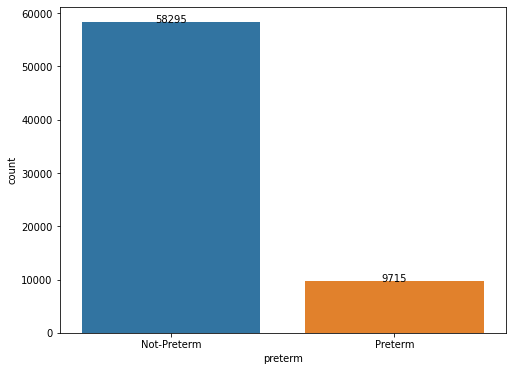

In [15]:
import seaborn as sns
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=cleaned_dataset, x='preterm')
plt.xticks([0, 1], ['Not-Preterm', 'Preterm'])
for p in ax.patches:
    # print(p)
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.savefig('BeforeSplitting.png', dpi=300)
plt.show()

In [40]:
cleaned_dataset.shape

(68010, 70)

In [16]:
numeric_cols = cleaned_dataset.select_dtypes(include=['number']).columns
print(len(numeric_cols))
categorical_cols = cleaned_dataset.select_dtypes(include=['object']).columns

52


In [17]:
numeric_cols = cleaned_dataset.select_dtypes(include=['int64','float64']).columns
print(len(numeric_cols))

51


In [43]:
unknown_code_map = {
    'mbstate_rec' : 3,
    'meduc' : 9,
    'fagecomb' : 99, 
    'fagerec11': 11, 
    'frace31': 99,
    'frace6': 9,
    'frace15': 99,
    'feduc': 9,
    'priorlive': 99,
    'priordead': 99,
    'priorterm': 99,
    'lbo_rec' : 9,
    'tbo_rec': 9,
    'illb_r': 999,
    'illb_r11': 99,
    'ilop_r': 999,
    'ilop_r11': 99,
    'ilp_r': 999,
    'ilp_r11': 99,
    'precare5': 5,
    'previs_rec': 12, 
    'cig_0': 99,
    'cig_1': 99,
    'cig_2': 99,
    'cig_3': 99,
    'cig0_r': 6,
    'cig1_r': 6,
    'cig2_r': 6,
    'cig3_r': 6,
    'm_ht_in': 99,
    'bmi': 99.9,
    'bmi_r': 9,
    'pwgt_r': 999,
    'dwgt_r':999,
    'wtgain': 99,
    'wtgain_rec': 9,
    'rf_cesarn': 99,
    'no_risks': 9,
    'no_infec': 9,
    'setorder_r': 9,
    'dlmp_mm': 99,
    'dlmp_yy': 9999      
    
}

In [44]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in cleaned_dataset.columns:
        cleaned_dataset[col] = cleaned_dataset[col].replace(code, pd.NA)


In [46]:
import pandas as pd

# Select numeric columns
numeric_cols = cleaned_dataset.select_dtypes(include=['int64', 'float64']).columns

# Calculate missing value percentage for each numeric column
missing_percent = cleaned_dataset[numeric_cols].isna().mean() * 100

# Create a dataframe
missing_df = pd.DataFrame({
    'Feature': missing_percent.index,
    'Missing_Percent': missing_percent.values
})

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
plt.figure(figsize=(16,14))
sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='pastel')
plt.xlabel('Missing Value Percentage (%)')
plt.ylabel('Numeric Features')
plt.title('Missing Value Percentage per Numeric Feature')
plt.xlim(0, 100)
plt.show()
# Filter only features with missing values > 0
missing_df = missing_df[missing_df['Missing_Percent'] > 0]

# Sort by missing percentage descending
missing_df = missing_df.sort_values(by='Missing_Percent', ascending=False).reset_index(drop=True)

print(missing_df)


In [46]:
cleaned_dataset = cleaned_dataset.drop(columns=['setorder_r'])


In [47]:
for col in unknown_code_map.keys():
    if col in cleaned_dataset.columns:
        # Replace unknown codes with NaN first (already done)
        median_value = cleaned_dataset[col].median()  # compute median ignoring NaN
        cleaned_dataset[col] = cleaned_dataset[col].fillna(median_value)  # fill missing


In [48]:
cleaned_dataset.isnull().sum()[cleaned_dataset.isnull().sum()>0]

Series([], dtype: int64)

# Train Test split

In [18]:
X = cleaned_dataset.drop(columns=['preterm'])  # your features
y = cleaned_dataset['preterm']                 # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Visualizing the Preterm vs Not_Preterm in Train and Test

# Using Seaborn

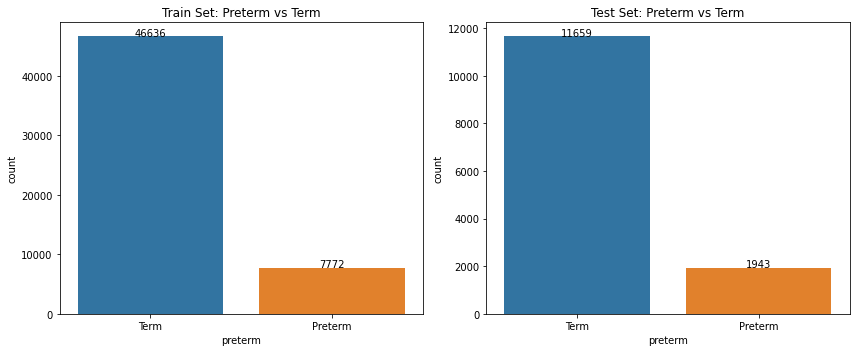

In [19]:
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Term','Preterm'])
axes[0].set_title('Train Set: Preterm vs Term')
for p in axes[0].patches:
    # print(p)
    height = p.get_height()
    axes[0].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')

    

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Term','Preterm'])
axes[1].set_title('Test Set: Preterm vs Term')
for p in axes[1].patches:
    # print(p)
    height = p.get_height()
    axes[1].text(p.get_x()+p.get_width()/2., height + 0.5,int(height), ha='center')
plt.tight_layout()
plt.show()


In [45]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
corr = X_train[numeric_cols].corr()

# Identify highly correlated pairs (threshold >0.9)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.88:
            corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

corr_pairs


[('cig1_r', 'cig0_r', 0.9891692662405885),
 ('cig2_r', 'cig0_r', 0.9877194828144874),
 ('cig2_r', 'cig1_r', 0.9974086245632029),
 ('cig3_r', 'cig0_r', 0.8941670316298108),
 ('cig3_r', 'cig1_r', 0.9023115482960605),
 ('cig3_r', 'cig2_r', 0.9038227927119574),
 ('setorder_r', 'dplural', -0.9827022464326702)]

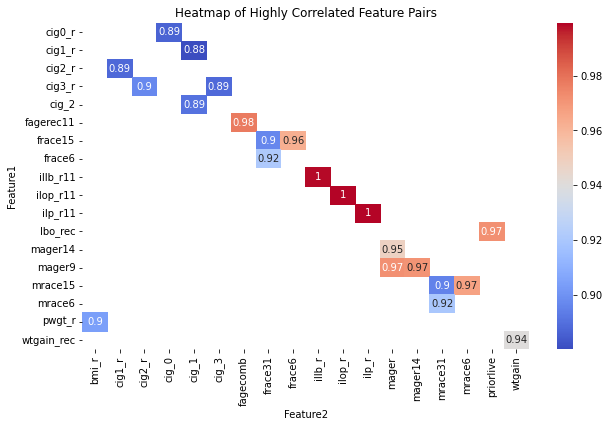

In [90]:
# Convert to a matrix
df_pairs = pd.DataFrame(corr_pairs, columns=['Feature1', 'Feature2', 'Correlation'])

# Pivot into matrix form
corr_matrix = df_pairs.pivot(index='Feature1', columns='Feature2', values='Correlation')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap of Highly Correlated Feature Pairs")

plt.show()

In [21]:
cols_to_drop = ['mager14', 'mager9', 'mrace31', 'mrace15', 'frace31', 'frace15',
                'lbo_rec', 'wtgain_rec', 'ilp_r11', 'ilop_r11', 'illb_r11', 'bmi_r', 'pwgt_r', 'fagerec11',
                'cig_3', 'cig_1', 'cig_0', 'cig_2']


In [22]:
X_train = X_train.drop(columns=cols_to_drop)
print(X_train.shape)


(54408, 51)


In [23]:
X_test = X_test.drop(columns = cols_to_drop)
print(X_test.shape)

(13602, 51)


In [24]:
X_train = X_train.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])

In [25]:
X_train = X_train.drop(columns=['no_risks', 'no_infec', 'cig_rec'])


In [29]:
X_test = X_test.drop(columns=['dlmp_yy', 'dlmp_mm', 'wic', 'previs', 'precare', 'mbstate_rec'])
X_test = X_test.drop(columns=['no_risks', 'no_infec', 'cig_rec'])


In [30]:
print(X_train.shape)
print(X_test.shape)

(54408, 42)
(13602, 42)


# Data Preprocessing

# Step 1: Continuous / Numeric Features Preprocessing   (12)

In [68]:
numeric_continuous_features = ['mager', 'fagecomb',
       'priorlive', 'priordead', 'priorterm', 'illb_r', 'ilop_r',
       'ilp_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn']
len(numeric_continuous_features)
# for i in numeric_continuous_features:
#     print(i, X_train[i].unique())

12

In [69]:
unknown_code_map = {
    'fagecomb' : 99, 'priorlive': 99,'priordead': 99,'priorterm': 99,'illb_r': 999,'ilop_r': 999,'ilp_r': 999,'m_ht_in': 99,
    'bmi': 99.9,'wtgain': 99,'rf_cesarn': 99
}
len(unknown_code_map)

11

In [70]:
unknown_code_map.items()

dict_items([('fagecomb', 99), ('priorlive', 99), ('priordead', 99), ('priorterm', 99), ('illb_r', 999), ('ilop_r', 999), ('ilp_r', 999), ('m_ht_in', 99), ('bmi', 99.9), ('wtgain', 99), ('rf_cesarn', 99)])

In [71]:
for col, code in unknown_code_map.items():
    # Only apply to columns that exist in the dataset
    if col in cleaned_dataset.columns:
        X_train[col] = X_train[col].replace(code, pd.NA)

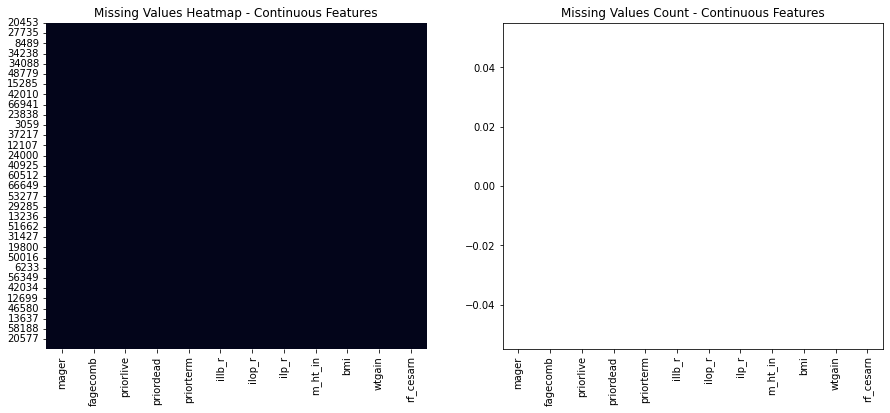

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.heatmap(X_train[numeric_continuous_features].isna(), cbar=False)
plt.title("Missing Values Heatmap - Continuous Features")
# plt.show()

plt.subplot(1, 2, 2)
X_train[numeric_continuous_features].isna().sum().plot(kind='bar')
plt.title("Missing Values Count - Continuous Features")
plt.show()


In [110]:
X_train['bmi'].value_counts()

99.900002    750
23.000000    669
28.299999    571
26.600000    492
24.000000    487
            ... 
68.300003      1
14.200000      1
51.299999      1
60.400002      1
55.500000      1
Name: bmi, Length: 808, dtype: int64

In [106]:
for col in unknown_code_map.keys():
    if col in X_train.columns:
        # Replace unknown codes with NaN first (already done)
        median_value = X_train[col].median()  # compute median ignoring NaN
        X_train[col] = X_train[col].fillna(median_value)

In [75]:
(X_train[numeric_continuous_features].isnull().sum()/X_train.shape[0])*100

mager        0.000000
fagecomb     8.406852
priorlive    0.362079
priordead    0.426408
priorterm    0.928172
illb_r       2.586017
ilop_r       2.370975
ilp_r        4.537936
m_ht_in      0.893251
bmi          0.000000
wtgain       2.716512
rf_cesarn    0.507278
dtype: float64

In [80]:
# import pandas as pd

# # Calculate missing value percentage for each numeric column
# missing_percent = cleaned_dataset[numeric_continuous_features].isna().mean() * 100

# # Create a dataframe
# missing_df = pd.DataFrame({
#     'Feature': missing_percent.index,
#     'Missing_Percent': missing_percent.values
# })

# missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
# plt.figure(figsize=(16,14))
# sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='pastel')
# plt.xlabel('Missing Value Percentage (%)')
# plt.ylabel('Numeric Features')
# plt.title('Missing Value Percentage per Numeric Feature')
# plt.xlim(0, 100)
# plt.show()
# # Filter only features with missing values > 0
# missing_df = missing_df[missing_df['Missing_Percent'] > 0]

# # Sort by missing percentage descending
# missing_df = missing_df.sort_values(by='Missing_Percent', ascending=False).reset_index(drop=True)

# print(missing_df)

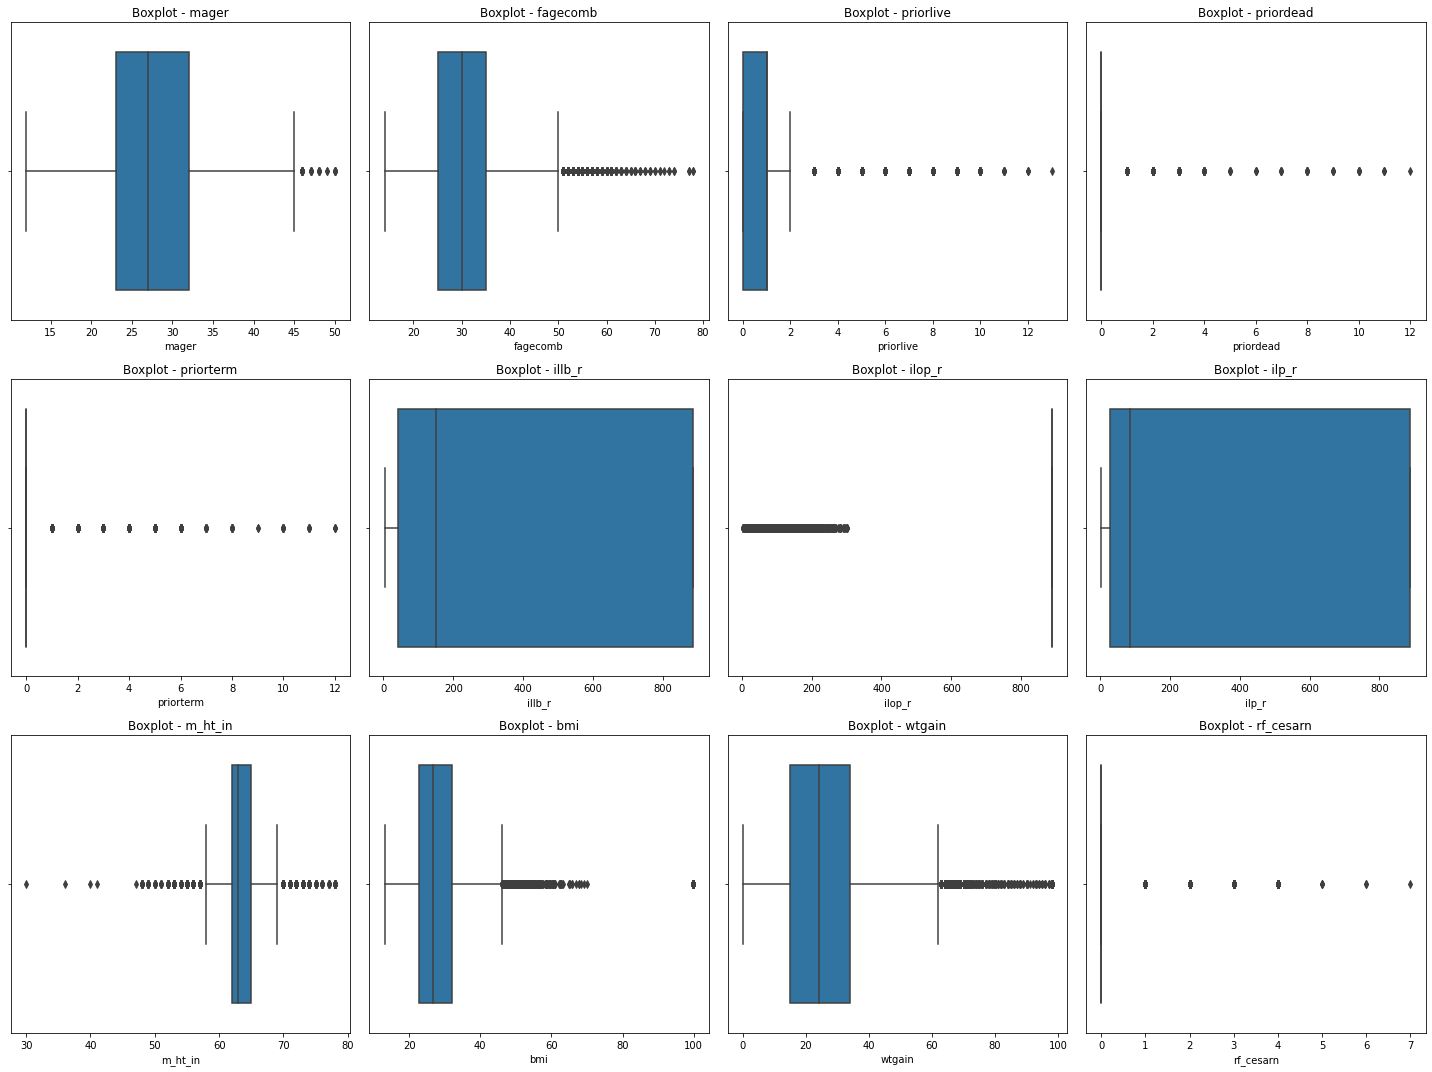

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = len(numeric_continuous_features)
cols = 4
rows = (num_features + cols - 1) // cols  

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))  
axes = axes.flatten() 
for i, col in enumerate(numeric_continuous_features):
    sns.boxplot(x=X_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot - {col}")


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [33]:
numeric_values = X_train.select_dtypes(include=['number']).columns
print(numeric_values)
# for i in numeric_values:
#     print(i, X_train[i].unique())

Index(['mager', 'mrace6', 'dmar', 'meduc', 'fagecomb', 'frace6', 'feduc',
       'priorlive', 'priordead', 'priorterm', 'tbo_rec', 'illb_r', 'ilop_r',
       'ilp_r', 'precare5', 'previs_rec', 'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r', 'm_ht_in', 'bmi', 'wtgain', 'rf_cesarn', 'dplural',
       'setorder_r'],
      dtype='object')


# Step 2: Ordinal Features Preprocessing (11)

In [92]:
ordinal_features = ['meduc', 'feduc',  'cig0_r', 'cig1_r', 'cig2_r',
       'cig3_r',  'precare5', 'previs_rec',  'dplural', 'tbo_rec', 'setorder_r']
len(ordinal_features)

11

In [98]:
for i in ordinal_features:
    print(i)
    print(X_train[i].value_counts())
    print("")

meduc
3    16179
6    12233
4     7914
5     7814
2     4507
7     3495
8     1254
1      611
9      401
Name: meduc, dtype: int64

feduc
3    18276
5     7923
4     7407
6     7127
9     5404
2     4501
7     1703
1     1043
8     1024
Name: feduc, dtype: int64

cig0_r
0    52855
6     1187
1      200
2       97
3       51
4       13
5        5
Name: cig0_r, dtype: int64

cig1_r
0    53016
6     1189
1      121
2       50
3       23
4        6
5        3
Name: cig1_r, dtype: int64

cig2_r
0    53059
6     1189
1       94
2       42
3       19
4        3
5        2
Name: cig2_r, dtype: int64

cig3_r
0    52800
6     1447
1      101
2       38
3       17
4        4
5        1
Name: cig3_r, dtype: int64

precare5
1    42243
2     8105
3     2052
5     1230
4      778
Name: precare5, dtype: int64

previs_rec
7     15002
6     10900
8     10571
9      5278
5      4512
4      2235
10     1346
12     1173
3      1089
11     1021
1       778
2       503
Name: previs_rec, dtype: int64

dplural

# Step 3: One-Hot Features (19)

In [95]:

all_features = X_train.columns.tolist()
one_hot_features = list(set(all_features) - set(numeric_continuous_features) - set(ordinal_features))
print(one_hot_features)
len(one_hot_features)

11
['rf_gdiab', 'rf_ehype', 'ip_syph', 'ip_hepb', 'rf_fedrg', 'rf_ppterm', 'ip_chlam', 'rf_ghype', 'ip_hepc', 'frace6', 'mar_p', 'rf_phype', 'mrace6', 'rf_artec', 'rf_inftr', 'rf_pdiab', 'dmar', 'ip_gon', 'rf_cesar']


19

In [84]:
missing_pct = X_train[ordinal_features].isna().mean() * 100
print("Missing percentage:\n", missing_pct)


Missing percentage:
 meduc         0.0
feduc         0.0
cig0_r        0.0
cig1_r        0.0
cig2_r        0.0
cig3_r        0.0
precare5      0.0
previs_rec    0.0
dplural       0.0
dtype: float64


In [93]:
X_train.shape

(54408, 42)

In [89]:
X_train['rf_ppterm'].unique()

array(['N', 'Y', 'U'], dtype=object)

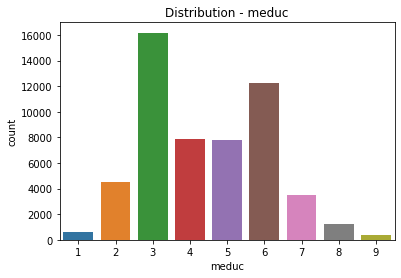

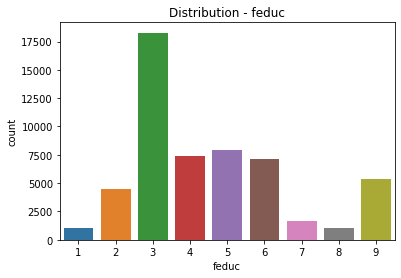

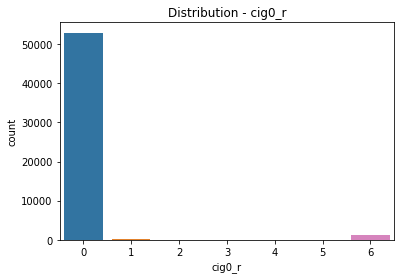

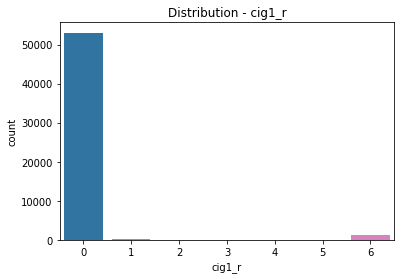

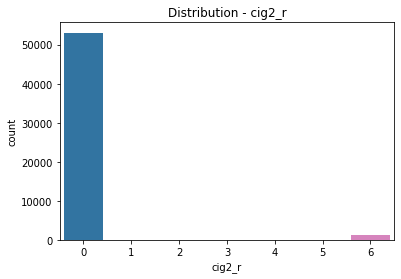

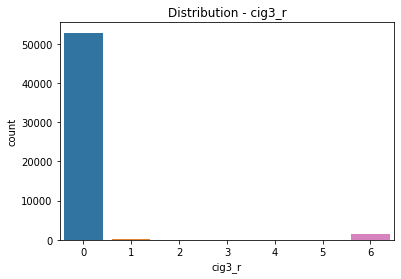

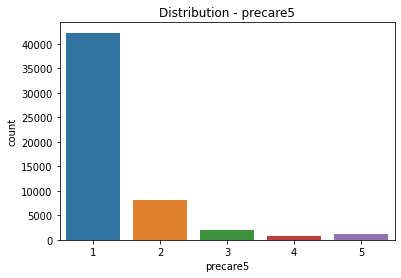

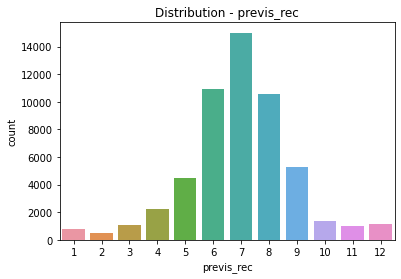

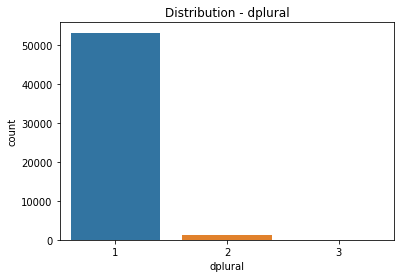

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ordinal_features:
    sns.countplot(x=X_train[col])
    plt.title(f"Distribution - {col}")
    plt.show()



# Applying